# Stable Diffusion with Hugging Face `diffusers`

Original: https://github.com/fastai/diffusion-nbs/

Adapted: Antonio Esteves, UMinho

## Introduction

This notebook is going to cover the basics of how to use Stable Diffusion to create and modify images using existing pipelines. We'll also take a brief look at the key components within the pipeline, while leaving further exploration of them to the deep dive notebook. Specifically, we will cover:
- Generating images from text using the `StableDiffusionPipeline` and experimenting with the available arguments
- Seeing some of the key pipeline components in action
    - The VAE that makes this a 'latent diffusion model'
    - The tokenizer and text encoder that process the text prompt
    - The UNet itself
    - The scheduler, and exploring different schedulers
- Replicating the sampling loop with the pipeline components
- Editing existing images with the Img2Img pipeline
- Using inpainting and Depth2Img pipelines.


# Setup

In [ ]:
%pip install -Uq diffusers ftfy accelerate

In [ ]:
# Installing 'transformers' from source for now
# since we need the latest version for 'depth2img'
%pip install -Uq git+https://github.com/huggingface/transformers

In [ ]:
import torch
import requests
from   PIL        import Image
from   io         import BytesIO
from   matplotlib import pyplot as plt

# We will explore several pipelines
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    StableDiffusionInpaintPipeline,
    StableDiffusionDepth2ImgPipeline
    )

# Function to download a image given its URL
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Download images to use in the inpainting example
img_url  = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

img_height = 512
img_width  = 512

init_image = download_image(img_url).resize(
    (img_height, img_width)
)
mask_image = download_image(mask_url).resize(
    (img_height, img_width)
)

In [ ]:
# Set the computing device
device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f'Computing device: {device}')

# Generating Images from Text

Let us load a Stable Diffusion pipeline and see what it can do. There are multiple different versions of Stable Diffusion, 1.x, 2.x, etc. To explore an older version, simply replace the model ID with the appropriate model (for example, we could try "CompVis/stable-diffusion-v1-4" or pick a model from the [dreambooth concepts library](https://huggingface.co/sd-dreambooth-library)).

In [ ]:
# Load the pipeline
model_id = "CompVis/stable-diffusion-v1-4"
pipe     = StableDiffusionPipeline.from_pretrained(model_id).to(device)

If we run out of GPU memory, there are some things we can do to reduce the RAM usage:
- Load the FP16 version (not supported on all systems). With this we may also need to convert tensors to torch.float16 when experimenting with individual components of the pipeline:

  ```
  pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    revision    = "fp16",
    torch_dtype = torch.float16
  ).to(device)
  ```

- Enable attention slicing. This reduces GPU memory usage at the cost of a small reduction in speed:

 `pipe.enable_attention_slicing()`
- Reduce the size of the images you're generating

Once the pipeline is loaded, we can generate an image based on a prompt with the following code:

In [ ]:
# Set up a random number's generator for reproducibility
generator = torch.Generator(device=device).manual_seed(47)

# Run the pipeline, showing some of the available arguments
pipe_output = pipe(
    prompt              = "Palette knife painting of an autumn cityscape", # What we want to generate
    negative_prompt     = "Oversaturated, blurry, low quality",            # What we do NOT want to generate
    height              = 480,        # Specify the image height
    width               = 640,        # Specify the image width
    guidance_scale      = 8,          # How strongly to follow the prompt
    num_inference_steps = 35,         # How many sampling steps to run
    generator           = generator   # Fixed random seed
)

# View the generated image
pipe_output.images[0]

We can play with the cell above, using a different prompt and different settings to see how they affect the output. Use a different random seed or remove the `generator` argument to get different results each time.

Key arguments to tweak:
- Width and height specify the size of the generated image. They must be divisible by **8** for the VAE to work (which we will see in a future section).
- The number of steps influences the generation quality. The default (50) works well, but in some cases you can get away with as few as 20 steps which is handy for experimentation.
- The negative prompt is used during the classifier-free guidance process, and can be a useful way to add additional control. You can leave it out, but many users find it useful to list some undesirable descriptions in the negative prompt as shown above.
- The `guidance_scale` argument determines how strong the classifier-free guidance (CFG) is. Higher scales push the generated images to better match the prompt, but if the scale is too high the results can become over-saturated and unpleasant.

One can take a look at the [Stable Diffusion Prompt Book](https://stability.ai/sdv2-prompt-book) for some ideas on how to write the prompts.

The following cell shows the effect of increasing the guidance scale.

In [ ]:
#@markdown Compare guidance scales:
cfg_scales = [1.1, 3, 5, 8, 12] #@param
prompt     = "A collie with a pink hat" #@param
fig, axs   = plt.subplots(1, len(cfg_scales), figsize=(16, 5))
for i, ax in enumerate(axs):
  im = pipe(
      prompt,
      height              = 480,
      width               = 480,
      guidance_scale      = cfg_scales[i],
      num_inference_steps = 35,
      generator           = torch.Generator(device=device).manual_seed(47)
  ).images[0]
  ax.imshow(im); ax.set_title(f'CFG scale = {cfg_scales[i]}');

We can adjust the values above to try different scales and prompts. Interpretation is subjective of course, but anything in the 8-12 range produces better results than values below or above this range.

# Pipeline Components

The `StableDiffusionPipeline` we are using is a little more complex than the `DDPMPipeline`. In addition to the UNet and the scheduler, there are a number of other components included in the pipeline.

In [ ]:
print(list(pipe.components.keys())) # List the pipeline components

To better understand how the pipeline works, let us briefly see each component in action individually and then put them all together to replicate the functionality of the pipeline for ourselves.

### 1. The VAE

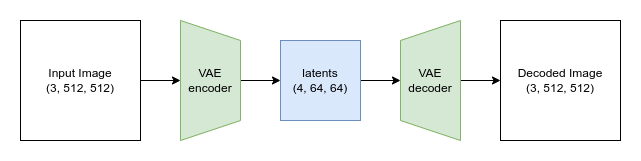

The VAE (variational autoencoder) is a type of model that can encode its input into a compressed representation and then decode this 'latent' representation back into something close to the original input. When generating images with Stable Diffusion, we first **generate the latents** by applying the diffusion process in the 'latent space' of the VAE, and then **decode them at the end** to view the resulting image.

Here is some code that takes an input image, encodes it to a latent representation and then decodes it again using the VAE.

In [ ]:
# Create a fake (random) image with values in the range (-1, 1))
images = torch.rand(1, 3, 512, 512).to(device) * 2 - 1
print("Input images shape:", images.shape)

# Encode the image into the latent space
with torch.no_grad():
  latents = 0.18215 * pipe.vae.encode(images).latent_dist.mean
print("Encoded latents shape:", latents.shape)

# Decode the latent tensor back to the image space
with torch.no_grad():
  decoded_images = pipe.vae.decode(latents / 0.18215).sample
print("Decoded images shape:", decoded_images.shape)

As we can see, the 512x512 image is compressed to a 64x64 latent representation (with four channels). This 8x reduction in each spatial dimension is the reason the specified width and height need to be multiples of 8.

Working with these information-rich 4x64x64 latents is more efficient than working with massive 512px images, allowing for faster diffusion models that take less resources to train and use. The VAE decoding process is not perfect, but it is good enough that the small quality tradeoff is generally worth it.

**Note**: The code example above includes the scaling factor of 0.18215 required to match the processing used during the Stable Diffusion training.

### 2. The Tokenizer and Text Encoder


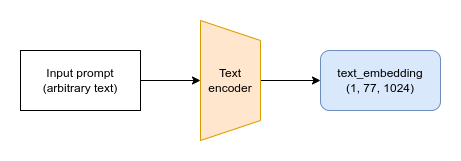


The goal of the text encoder is to turn an input string (the prompt) into a numerical representation that can be fed to the UNet as conditioning. The text is first turned into a series of tokens using the pipeline's tokenizer. The text encoder has a vocabulary of about 50k tokens - any word that is not in this vocabulary is split into smaller sub-words. The tokens are then fed through the text encoder model itself - a transformer model that was originally trained as the text encoder for CLIP. The hope is that this pretrained transformer model has learnt rich representations of text that will be useful for the diffusion task too.

Let us test this process by encoding an example prompt, first manually tokenizing and feeding it through the text encoder and then using the pipelines `encode_prompt` method to show the full process including padding/truncating the length to the maximum length of 77 tokens.

In [ ]:
# Tokenizing and encoding an example prompt manually

# Tokenize the prompt
input_ids = pipe.tokenizer(["A painting of a flooble"])['input_ids']
print("Input ID -> decoded token")
for input_id in input_ids[0]:
  print(f"{input_id: 7} -> {pipe.tokenizer.decode(input_id)}")

# Pass the tokens through the CLIP text encoder
input_ids = torch.tensor(input_ids).to(device)
with torch.no_grad():
  text_embeddings = pipe.text_encoder(input_ids)['last_hidden_state']
print("Text embeddings shape:", text_embeddings.shape)

In [ ]:
# Get the final text embeddings using the pipeline's 'encode_prompt' function
text_embeddings = pipe.encode_prompt("A painting of a flooble", device, 1, True, '')

In [ ]:
print(text_embeddings[0].shape)
print(text_embeddings[0])

These text embeddings (the so-called 'hidden states' of the last transformer block in the text encoder model) will be fed to the UNet as an additional argument to the `forward` method, which we will see in the next section.

### 3. The UNet

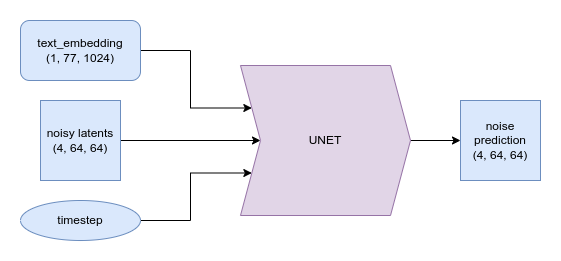

The UNet takes a noisy input and predicts the noise. Here, the input is not an image but is instead a latent representation of an image. And in addition to the timestep conditioning, this UNet also takes in the text embeddings of the prompt as an additional input. Next, we use the UNet to make predictions on some dummy data.

In [ ]:
# Dummy inputs
timestep        = pipe.scheduler.timesteps[0]          # sample a timestep
latents         = torch.randn(1, 4, 64, 64).to(device) # define a random latent sample
text_embeddings = torch.randn(1, 77, 768).to(device)   # define random text embeddings

# Make the noise prediction using UNet, conditioned on timestep and text embeddings
with torch.no_grad():
  unet_output = pipe.unet(latents, timestep, text_embeddings).sample
print('UNet output shape:', unet_output.shape) # The UNet output has the same shape as the input latents

### 4. The Noise Scheduler

The scheduler stores the noise schedule and manages updating the noisy sample based on the model predictions. The default scheduler is a `PNDMScheduler`, but you can use others (such as `LMSDiscreteScheduler`) as long as they are initialized with the same configuration.

We can plot the noise schedule to see the noise level (based on $\bar{\alpha}$) over time.

In [ ]:
plt.plot(pipe.scheduler.alphas_cumprod, label=r'$\bar{\alpha}$')
plt.xlabel('Timestep (high noise -> low noise)');
plt.title('Noise schedule');plt.legend();

We can try a different noise scheduler using the following code.

In [ ]:
from diffusers import LMSDiscreteScheduler

# Replace the scheduler by 'LMSDiscreteScheduler'
pipe.scheduler = LMSDiscreteScheduler.from_config(pipe.scheduler.config)

# Print the scheduler configuration
print('Scheduler configuration:', pipe.scheduler)

# Generate an image with the new scheduler
pipe(
  prompt    = "Palette knife painting of an winter cityscape",
  height    = 480,
  width     = 480,
  generator = torch.Generator(device=device).manual_seed(42)
).images[0]

One can find  more information about the different noise schedulers [here](https://huggingface.co/docs/diffusers/using-diffusers/schedulers).

### Sampling Loop

Now that we have seen all the pipeline components in action, we can put them together to replicate the functionality of the pipeline.

In [ ]:
guidance_scale      = 8 #@param
num_inference_steps = 30 #@param
prompt              = "Beautiful picture of a wave breaking" #@param
negative_prompt     = "zoomed in, blurry, oversaturated, warped" #@param

# Encode the prompt
text_embeddings1 = pipe.encode_prompt(
  prompt,
  device,
  1,
  True,
  negative_prompt
)

# To solve the difference between deprecated 'pipe._encode_prompt()'
# and 'pipe.encode_prompt()'
text_embeddings2 = (text_embeddings1[1], text_embeddings1[0])
text_embeddings  = torch.cat(text_embeddings2, dim=0)

# Create a random latent sample (z_T)
latents  = torch.randn(
  (1, 4, 64, 64),
  device    = device,
  generator = generator,
)
latents *= pipe.scheduler.init_noise_sigma

# Prepare the noise scheduler
pipe.scheduler.set_timesteps(num_inference_steps, device=device)

# Loop through the sampling timesteps
for i, t in enumerate(pipe.scheduler.timesteps):

  # Duplicate the latent samples if we are applying classifier free guidance
  latent_model_input = torch.cat([latents] * 2)

  # Apply any scaling required by the noise scheduler
  latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

  # Predict the noise residual with the UNet
  with torch.no_grad():
    noise_pred = pipe.unet(
      latent_model_input,
      t,
      encoder_hidden_states = text_embeddings
    ).sample

  # Apply the guidance
  noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
  noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

  # Compute the previous noisy sample: given x_t predict x_{t-1}
  latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

# Decode the final latents (z_0) into an image (x_0)
with torch.no_grad():
  image = pipe.decode_latents(latents.detach())

# View the generated image
pipe.numpy_to_pil(image)[0]

In most cases it will be easier to use the existing pipelines, but implementing the sampling loop is useful for understanding and modifying each component. To see this code and all the different components explored and modified in depth, check out the 'Stable Diffusion Deep Dive' [notebook](https://github.com/fastai/diffusion-nbs/blob/master/Stable%20Diffusion%20Deep%20Dive.ipynb) and [video](https://m.youtube.com/watch?v=0_BBRNYInx8) for a more thorough exploration.

# Additional Pipelines

Besides generating images from a prompt, in this section we will demonstrate other pipelines to get some insight on the other tasks that Stable Diffusion can be used for. In some cases, these tasks require downloading new models.

## Image-to-image

In the examples so far, we have generated images completely from scratch by starting from random latents and applying the full diffusion denoising loop. But we do not have to start from scratch. The `img2img` pipeline first encodes an existing image into a set of latents, then adds some noise to the latents and uses that as the starting point. The amount of noise added and the number of denoising steps applied determine the strength of the `img2img` process. Adding just a small amount of noise (low strength) will result in very little change, while adding the maximum amount of noise and running the full denoising process will give an image that hardly resembles the input apart from some similarities on overall structure.

To better understand the `img2img` process, let us manually implement the pipeline. This approach will help clarify how latents are encoded, the noise is added, and the diffusion is applied. After manually constructing the pipeline, we will see how the `diffusers` library provides a ready-to-use `StableDiffusionImg2ImgPipeline` for simplicity and efficiency.

SO, let us manually implement the `img2img` pipeline.

### Image-to-Image Pipeline

In [ ]:
import numpy as np

# Encode 'init_image' downloaded in the beginning of the notebook
# using the VAE encoder

init_image_tensor = torch.from_numpy(np.array(init_image).transpose(2, 0, 1)).float() / 255.0 # convert from [0:255] to [0:1]
init_image_tensor = 2.0 * init_image_tensor - 1.0             # convert from [0:1] to [-1:+1]
init_image_tensor = init_image_tensor.unsqueeze(0).to(device) # add the batch dimension tho the image

with torch.no_grad():
    init_image_latents = pipe.vae.encode(init_image_tensor).latent_dist.sample() * pipe.vae.config.scaling_factor

In [ ]:
guidance_scale      = 7.5 #@param
num_inference_steps = 30  #@param
strength            = 0.6
prompt              = "An oil painting of a man on a bench" #@param

# Encode the prompt
text_embeddings1 = pipe.encode_prompt(prompt, device, 1, True, '')

# To solve the difference between deprecated 'pipe._encode_prompt()'
# and 'pipe.encode_prompt()'
text_embeddings2 = (text_embeddings1[1], text_embeddings1[0])
text_embeddings  = torch.cat(text_embeddings2, dim=0)

# Prepare the noise scheduler
pipe.scheduler.set_timesteps(num_inference_steps, device=device)

# Prepare latent variables
# We do not use all timesteps in the noise scheduler.
# Calculate a subset of timesteps based on `strength` to apply to the initial image.
init_timestep = min(int(num_inference_steps * strength), num_inference_steps)
t_start       = max(num_inference_steps - init_timestep, 0)
timesteps     = pipe.scheduler.timesteps[t_start:]

# The first timestep of the new 'timesteps' will be the starting point for adding noise to the initial image.
latent_timestep = timesteps[:1]

# Add noise to 'init_image_latents' at the noise level specified by 'latent_timestep'.
noise = torch.randn(
  (1, 4, 64, 64),
  device    = device,
  generator = torch.Generator(device=device).manual_seed(47)
)
latents = pipe.scheduler.add_noise(
  init_image_latents,
  noise,
  latent_timestep
)

# Loop through the sampling timesteps
for i, t in enumerate(timesteps):

  # Duplicate the latent samples if we are applying classifier free guidance
  latent_model_input = torch.cat([latents] * 2)

  # Apply the scaling required by the noise scheduler
  latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

  # Predict the noise to remove with the UNet
  with torch.no_grad():
    noise_pred = pipe.unet(
      latent_model_input,
      t,
      encoder_hidden_states = text_embeddings,
    ).sample

  # Apply the guidance
  noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
  noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

  # Compute the previous noisy sample: given x_t predict x_{t-1}
  latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

# Decode the final latents (z_0) into an image (x_0)
latents_norm = latents / pipe.vae.config.scaling_factor

with torch.no_grad():
    result_image = pipe.vae.decode(latents_norm).sample

# Convert the image values to the pixel range [0:255]
result_image = (result_image / 2 + 0.5).clamp(0, 1).squeeze()
result_image = (result_image.permute(1, 2, 0) * 255).to(torch.uint8).cpu().numpy()
result_image = Image.fromarray(result_image)

# View the sampled image
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(init_image);axs[0].set_title('Input image')
axs[1].imshow(result_image);axs[1].set_title('Sampled image');

Now that we have manually implemented the img2img process, let us see how to achieve the same results more efficiently using the `StableDiffusionImg2ImgPipeline` provided by the `diffusers` library.

This pipeline requires no special models, so as long as the model ID is the same as our text-to-image example above, no new files will need to be downloaded.

### Img2Img Pipeline

In [ ]:
# Loading an Img2Img pipeline
model_id     = "CompVis/stable-diffusion-v1-4" # "stabilityai/stable-diffusion-2-1-base"
img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(model_id).to(device)

In the Setup section we loaded an example `init_image` to use for this demo, but we can replace it with other image. Here is the pipeline in  action.

In [ ]:
# Apply the Img2Img pipeline
result_image = img2img_pipe(
    prompt   = "An oil painting of a man on a bench",
    image    = init_image, # The starting image
    strength = 0.6,        # 0 for no change, 1.0 for maximum changes
).images[0]

# View the result
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(init_image);axs[0].set_title('Input image')
axs[1].imshow(result_image);axs[1].set_title('Sampled image');

Here, we can experiment more with this pipeline. For example, using other initial image or applying different strengths and prompts. We can tune many of the same arguments that we used in the text-to-image pipeline, such as the image size or the number of denoising steps.

## In-Painting

What if we wanted to keep some of the input image unchanged but generate something new in other parts? This is called inpainting. While this can be done with the same model as before, via the `StableDiffusionInpaintPipelineLegacy` pipeline, we can get better results by using a custom fine-tuned version of Stable Diffusion that takes a masked image and the mask itself as additional conditioning. The mask image should be the same shape as the input image, with white in the areas to be replaced and black in the areas to be keep unchanged.

To gain a deeper understanding of the inpainting process, let us manually implement the logic behind the `StableDiffusionInpaintPipelineLegacy` pipeline. This approach will clarify how inpainting works at a lower level and provides insight into how Stable Diffusion processes inputs. Once we have completed this task, we will explore the fine-tuned pipeline for comparison. Here, is how we can manually implement the inpainting pipeline and apply it to the example image and mask loaded in the Setup section.



![inpainting from_scratch](https://raw.githubusercontent.com/metamath1/diffusion-models-class/unit3/implement_img2img_inpaint/unit3/inpaint_from_scratch.png)

### Inpainting Pipeline

In [ ]:
# Resize the mask image to the latent's size
mask_image_latent_size = mask_image.resize((64,64))
mask_image_latent_size = torch.tensor( (np.array(mask_image_latent_size)[...,0] > 5).astype(np.float32) )
plt.imshow(mask_image_latent_size.numpy(), cmap='gray')

mask_image_latent_size = mask_image_latent_size.to(device)
mask_image_latent_size.shape

Let us write the denoising loop for the inpainting task.

In [ ]:
guidance_scale      = 8  #@param
num_inference_steps = 30 #@param
prompt              = "A small robot, high resolution, sitting on a park bench"
negative_prompt     = "zoomed in, blurry, oversaturated, warped"
generator           = torch.Generator(device=device).manual_seed(42)

# Encode the prompt
text_embeddings1 = pipe.encode_prompt(prompt, device, 1, True, negative_prompt)

# To solve the difference between deprecated 'pipe._encode_prompt()'
# and 'pipe.encode_prompt()'
text_embeddings2 = (text_embeddings1[1], text_embeddings1[0])
text_embeddings  = torch.cat(text_embeddings2, dim=0)

# Create the initial random latent
latents  = torch.randn(
  (1, 4, 64, 64),
  device    = device,
  generator = generator
)
latents *= pipe.scheduler.init_noise_sigma

# Prepare the noise scheduler
pipe.scheduler.set_timesteps(num_inference_steps, device=device)

for i, t in enumerate(pipe.scheduler.timesteps):
    # Duplicate the latent samples if we are applying classifier-free guidance
    latent_model_input = torch.cat([latents] * 2)

    # Apply the scaling required by the noise scheduler
    latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    # Predict the noise to remove with the U-Net
    with torch.no_grad():
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

    # Apply the classifier-free guidance
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    # Compute the previous noisy sample: given z_t predict z_{t-1}
    latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]

    # Perform inpainting to fill in the masked areas
    if i < len(pipe.scheduler.timesteps)-1:
        # Add noise to the original image's latent at the previous timestep t-1
        noise      = torch.randn(init_image_latents.shape, generator=generator, device=device, dtype=torch.float32)
        background = pipe.scheduler.add_noise(init_image_latents, noise, torch.tensor([pipe.scheduler.timesteps[i+1]]))

        latents    = latents*mask_image_latent_size # white in the areas
        background = background * (1-mask_image_latent_size) # black in the areas

        # Combine the generated and original image latents based on the mask
        latents += background

# Decode the final latents (z_0) into an image (x_0)
latents_norm = latents / pipe.vae.config.scaling_factor

with torch.no_grad():
    inpainted_image = pipe.vae.decode(latents_norm).sample

# Convert the image values to the pixel range [0:255]
inpainted_image = (inpainted_image / 2 + 0.5).clamp(0, 1).squeeze()
inpainted_image = (inpainted_image.permute(1, 2, 0) * 255).to(torch.uint8).cpu().numpy()
inpainted_image = Image.fromarray(inpainted_image)

inpainted_image

### Inpainting Pipeline

Now that we have manually implemented the inpainting pipeline, let us see how to use a fine-tuned pipeline designed specifically for the inpainting task. Here is how we load such a pipeline and apply it to the example image and mask loaded in the Setup section.

![inpainting from_scratch](https://raw.githubusercontent.com/huggingface/diffusion-models-class/main/unit3/inpaint_w_border.jpg)

In [ ]:
del img2img_pipe
torch.cuda.empty_cache()

In [ ]:
# Load the inpainting pipeline (requires a suitable inpainting model)

# "stabilityai/stable-diffusion-2-inpainting"
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd-legacy/stable-diffusion-inpainting"
)
pipe = pipe.to(device)

In [ ]:
# Inpaint with a prompt for what we want the result to look like
prompt = "A small robot, high resolution, sitting on a park bench"
image  = pipe(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

# View the result
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(init_image);axs[0].set_title('Input image')
axs[1].imshow(mask_image);axs[1].set_title('Mask')
axs[2].imshow(image);axs[2].set_title('Inpainted image');

This can be especially powerful when combined with another model to automatically generate masks. For example, [this demo space](https://huggingface.co/spaces/nielsr/text-based-inpainting) uses a model called CLIPSeg to mask out an object to be replaced based on a text description.

### Aside: Managing Your Model Cache

Exploring different pipelines and model variants can fill up your disk space. You can see which models are currently downloaded with:

In [ ]:
!ls ~/.cache/huggingface/hub/ # List the contents of the cache directory

Check out [the docs on caching](https://huggingface.co/docs/huggingface_hub/main/en/how-to-cache) to see how to view and manage your cache effectively.

## Depth2Image


![depth to image examples](https://images.squarespace-cdn.com/content/v1/6213c340453c3f502425776e/3d0d3b3f-94ca-43eb-bb4d-79af0f4d10ac/Stability+AI+Stable+Diffusion+V2+Depth2Img.jpg?format=1500w)
_Input image, depth image and generated examples (image source: StabilityAI)_

Img2Img is great, but sometimes we want to create a new image with the composition of the original but completely different colours or textures. It can be difficult to find an Img2Img strength that preserves what we would like from the layout without also keeping the input colors.

Time for another fine-tuned model. This one accepts depth information as additional conditioning when generating a new image. The pipeline uses a depth estimation model to create a depth map, which is then fed to the fine-tuned UNet when generating images to (hopefully) preserve the depth and structure of the initial image while filling in completely new content.

In [ ]:
# Load the Depth2Img pipeline (requires a suitable model)
pipe = StableDiffusionDepth2ImgPipeline.from_pretrained("radames/stable-diffusion-2-depth-img2img")
# "stabilityai/stable-diffusion-2-depth"
pipe = pipe.to(device)

In [ ]:
# Inpaint with a prompt for what we want the result to look like
prompt = "An oil painting of a man on a bench"
image  = pipe(prompt=prompt, image=init_image).images[0]

# View the result
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].imshow(init_image);axs[0].set_title('Input Image')
axs[1].imshow(image);axs[1].set_title('Result');

Note how the output compares to the img2img example - here there is much more color variation, but the overall structure is still faithful to the original. This is not ideal in this case since the man has been given some extremely weird anatomy to match the dog shape, but in some cases this is extraordinarily useful. For an example of the 'killer app' for this approach, check out [this tweet](https://twitter.com/CarsonKatri/status/1600248599254007810?s=20&t=BlzSK26sfqi2336SN0gKpQ) showing the depth model being used to texture a 3D scene!